# Regression

using california housing dataset (large version)

using keras functional api

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import datasets, layers, Model
from keras.utils import plot_model

## 1- Data Preparation

In [2]:
(train_data, train_targets), (test_data, test_targets) = datasets.california_housing.load_data()

In [3]:
print(train_data.shape)
print(train_targets.shape)
print(test_data.shape)
print(test_targets.shape)

(16512, 8)
(16512,)
(4128, 8)
(4128,)


### Pre-processing

In [4]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

x_train = (train_data - mean)/std
x_test = (test_data - mean)/std

In [5]:
y_train = train_targets / 10_000
y_test = test_targets / 10_000

## Functional API in Models

In [30]:
x_train_1 = x_train[:, :3]
x_train_2 = x_train[:, 3:]

print(x_train_1.shape)
print(x_train_2.shape)

(16512, 3)
(16512, 5)


In [31]:
x_test_1 = x_test[:, :3]
x_test_2 = x_test[:, 3:]

### 1- Two inputs / One output

In [24]:
inp1 = layers.Input(shape=(3,))
inp2 = layers.Input(shape=(5,))

L1 = layers.Dense(32, activation='relu')(inp2)
L2 = layers.Dense(32, activation='relu')(L1)

concat = layers.Concatenate()([inp1, L2])

L3 = layers.Dense(16, activation='relu')(concat)
L4 = layers.Dense(8, activation='relu')(L3)

out = layers.Dense(1)(L4)

model_fn = Model(inputs=[inp1, inp2], outputs=out)

model_fn.summary()
model_fn.save('model_init_1.keras')

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)   │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_31 (Dense)              │ (None, 32)                │             192 │ input_layer_14[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_13 (InputLayer)   │ (None, 3)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_32 (Dense)              │ (None, 32)                │           1,056 │ dense_31[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_4 (Concatenate)   │ (None, 35)                │               0 │ input_layer_13[0][0],      │
│                               │                           │                 │ dense_32[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_33 (Dense)              │ (None, 16)                │             576 │ concatenate_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_34 (Dense)              │ (None, 8)                 │             136 │ dense_33[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_35 (Dense)              │ (None, 1)                 │               9 │ dense_34[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,969 (7.69 KB)

 Trainable params: 1,969 (7.69 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [28]:
model_fn.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

In [29]:
history = model_fn.fit(x=[x_train_1, x_train_2], y=y_train,
                       epochs=50, batch_size=64,
                       validation_split=0.2)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 275.6875 - mean_absolute_error: 12.6057 - val_loss: 89.6796 - val_mean_absolute_error: 6.8775
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 70.8526 - mean_absolute_error: 6.1992 - val_loss: 57.8441 - val_mean_absolute_error: 5.7628
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.0260 - mean_absolute_error: 5.4705 - val_loss: 50.7266 - val_mean_absolute_error: 5.1694
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50.0552 - mean_absolute_error: 5.1805 - val_loss: 47.9778 - val_mean_absolute_error: 5.0446
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47.3635 - mean_absolute_error: 5.0082 - val_loss: 45.4847 - val_mean_absolute_error: 4.8587
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45.4527 - mean_absolute_error: 4.8923 - val_loss: 43.9662 - val_mean_absolute_error: 4.7860
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43.5672 - mean_absolute_er

#### Evaluation

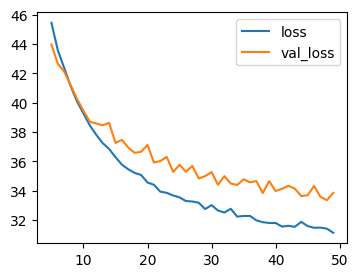

In [30]:
history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']][5:].plot(figsize=(4,3))
plt.show()

In [34]:
mse, mae = model_fn.evaluate([x_test_1, x_test_2], y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 339693.98498535156
MAE: 40619.31610107422


### 2- Two inputs / Two outputs

In [16]:
inp1 = layers.Input(shape=(3,))
inp2 = layers.Input(shape=(5,))

L1 = layers.Dense(32, activation='relu')(inp2)
L2 = layers.Dense(32, activation='relu')(L1)

concat = layers.Concatenate()([inp1, L2])

L3 = layers.Dense(16, activation='relu')(concat)
L4 = layers.Dense(8, activation='relu')(L3)

out1 = layers.Dense(1, name='out1')(L3)
out2 = layers.Dense(1, name='out2')(L4)

model_fn_2 = Model(inputs=[inp1, inp2],
                   outputs=[out1, out2])

model_fn_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 32)                │             192 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 3)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 32)                │           1,056 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 35)                │               0 │ input_layer_2[0][0],       │
│                               │                           │                 │ dense_7[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 16)                │             576 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 8)                 │             136 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ out1 (Dense)                  │ (None, 1)                 │              17 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ out2 (Dense)                  │ (None, 1)                 │               9 │ dense_9[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,986 (7.76 KB)

 Trainable params: 1,986 (7.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_fn_2.save('model_init_2.keras')

#### Training

In [18]:
model_fn_2.compile(
    optimizer='adam',
    loss=['mse', 'mse'],
    metrics=['mae', 'mae']
)

In [19]:
history_2 = model_fn_2.fit(x=[x_train_1, x_train_2],
                           y=[y_train, y_train],
                           epochs=50, batch_size=64,
                           validation_split=0.2)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 534.0453 - out1_loss: 261.3220 - out1_mae: 12.1805 - out2_loss: 271.6577 - out2_mae: 12.4780 - val_loss: 194.0339 - val_out1_loss: 96.6156 - val_out1_mae: 6.9739 - val_out2_loss: 97.8866 - val_out2_mae: 7.0399
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 147.0967 - out1_loss: 73.0571 - out1_mae: 6.1485 - out2_loss: 73.8403 - out2_mae: 6.2271 - val_loss: 113.4752 - val_out1_loss: 56.4106 - val_out1_mae: 5.5042 - val_out2_loss: 57.2415 - val_out2_mae: 5.6095
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.9835 - out1_loss: 54.7400 - out1_mae: 5.3872 - out2_loss: 55.4603 - out2_mae: 5.4535 - val_loss: 102.6193 - val_out1_loss: 51.2264 - val_out1_mae: 5.1663 - val_out2_loss: 51.6651 - val_out2_mae: 5.2066
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101.1153 - out1_loss: 50.3117 - out1_mae: 5.1632 - out2_loss: 50.7438 - out2_mae: 5.2034 - val_loss: 95.8633 - val_out1_loss: 47.9513 - va

#### Evaluation

In [21]:
history_2.history.keys()

dict_keys(['loss', 'out1_loss', 'out1_mae', 'out2_loss', 'out2_mae', 'val_loss', 'val_out1_loss', 'val_out1_mae', 'val_out2_loss', 'val_out2_mae'])

In [22]:
history_df_2 = pd.DataFrame(history_2.history)

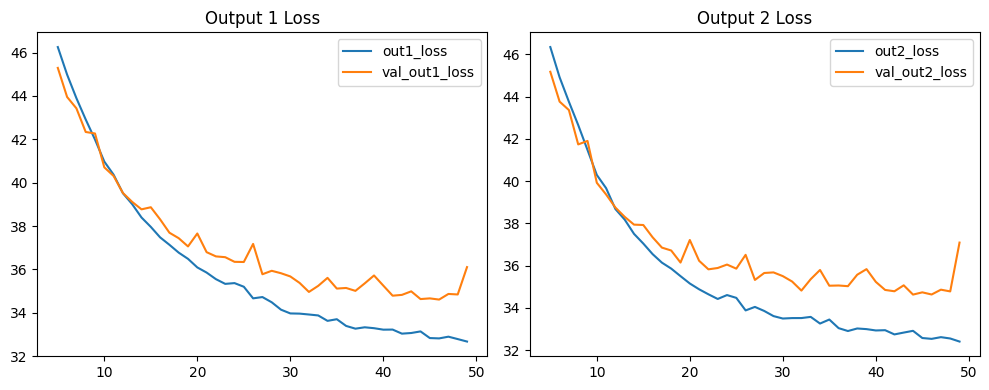

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot: out1_loss and val_out1_loss
history_df_2[['out1_loss', 'val_out1_loss']][5:].plot(ax=ax1)
ax1.set_title('Output 1 Loss')
ax1.legend()

# Second subplot: out2_loss and val_out2_loss
history_df_2[['out2_loss', 'val_out2_loss']][5:].plot(ax=ax2)
ax2.set_title('Output 2 Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [34]:
eval_results = model_fn_2.evaluate([x_test_1, x_test_2],
                                   [y_test, y_test], verbose=0)

print('MAE (out_1):', eval_results[3]*10_000)
print('MAE (out_2):', eval_results[4]*10_000)

MAE (out_1): 43261.17515563965
MAE (out_2): 43689.83745574951


> out_1 is slightly better than out_2
>> So we don't need the L4 layers and can remove it safely